In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os


# Configuração base
sns.set_style("whitegrid")

print("⏳ Baixando dataset da Olist do Kaggle...")
try:
    path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
    print(f"✅ Arquivos baixados em: {path}")

    # Carregando apenas 3 tabelas essenciais para o nosso escopo
    orders = pd.read_csv(os.path.join(path, "olist_orders_dataset.csv"))
    order_items = pd.read_csv(os.path.join(path, "olist_order_items_dataset.csv"))
    products = pd.read_csv(os.path.join(path, "olist_products_dataset.csv"))

    print("✅ DataFrames 'orders', 'order_items' e 'products' carregados com sucesso!")
except Exception as e:
    print(f"❌ Erro ao ler arquivos: {e}")

⏳ Baixando dataset da Olist do Kaggle...
Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
✅ Arquivos baixados em: /kaggle/input/brazilian-ecommerce
✅ DataFrames 'orders', 'order_items' e 'products' carregados com sucesso!


#📦 Desafio de Negócios: Olist E-commerce Analytics.
Contexto: Você é o novo Cientista de Dados da Olist. Você tem acesso a três bases de dados:

- ```orders```: Status do pedido e datas.
- ```order_items```: O que foi comprado, preço (price) e valor do frete (freight_value).
- ```products```: Categoria do produto e peso físico (product_weight_g).

## Requisições da Diretoria:
O board de diretores enviou 5 requisições de negócios.

### 1. Consolidação da Base (Data Engineering).

- A Demanda: A equipe de logística precisa de uma visão única (tabela mestra) que mostre as informações do pedido, os itens contidos nele e as características físicas desse produto (categoria e peso).
- A Regra: Queremos analisar exclusivamente os pedidos que possuam itens registrados e cujos produtos existam no nosso catálogo. Pedidos vazios ou produtos órfãos devem ficar de fora. Crie essa tabela e chame-a de ```df_master```.

In [75]:
df_master = products.merge(order_items, on = "product_id", suffixes = ["_products", "_orders_items"] )
df_master = df_master.merge(orders, on = "order_id", suffixes = [None, "_orders"])


### 2. Regra de Negócio de Frete (Tooling & Robustness).

- A Demanda: O financeiro quer calcular uma 'Taxa de Risco' para os fretes. A regra matemática é simples:</br></br>
 $$Taxa = Valor do Frete / Preço do Produto$$</br>
- A Regra: Crie uma ferramenta (função) reutilizável para este cálculo. No entanto, o sistema antigo às vezes exportava letras no lugar de números. A sua ferramenta deve ser inteligente o suficiente para não quebrar o código quando encontrar um texto, retornando 0 nestes casos. Além disso, a ferramenta deve bloquear ativamente (levantar um erro claro) caso receba um preço de produto negativo.

In [127]:
def taxa_risco(valor = 0, preco = 1):

  """Calcula a taxa de risco de um frete.
  Valores padrão previnem divisão por zero se não
  forem devidamente definidos, evitando erros."""


  try:
    valor = float(valor)
    preco = float(preco)

    if preco < 0:
        raise ValueError("Preço negativo, verifique a entrada")

    return valor / preco

  except (ValueError, TypeError):
    return 0.0

  except ZeroDivisionError:
    return 0.0

### 3. Aplicação da Regra (Data Transformation).

- A Demanda: Aplique a calculadora de 'Taxa de Risco' na nossa base consolidada (```df_master```), criando uma nova coluna com este resultado.
- A Regra: Utilize a abordagem mais otimizada e idiomática do Python para aplicar essa regra linha a linha, sem usar loops ```for``` tradicionais.

In [128]:
df_master["risk"] = df_master.apply(lambda x: taxa_risco(x["freight_value"], x["price"]), axis=1)

### 4. Gerador de Relatórios (Analytics).

- A Demanda: A diretoria precisa extrair métricas rápidas de preços por categoria de produto sem ter que reescrever código toda vez.
- A Regra: Construa um gerador (função) que receba a base de dados consolidada e o nome de uma categoria específica. Ele deve processar esses dados e entregar, de uma só vez, duas métricas sobre a coluna ```price``` dessa categoria: a média e a mediana. Teste o seu gerador solicitando os dados da categoria ```beleza_saude``` e exiba os resultados na tela.

In [137]:
def metricas_base(df, coluna, categoria, col_valor= "price"):
  """Essa função calcula a média e a mediana de
      preço do dataframe definido no primeiro parâmetro
      baseado na coluna requerida no segundo parâmetro e seu valor no
      terceiro parâmetro. A variavel alvo por padrão é a coluna 'price'."""

  try:

    dados_filtrados = df[df[coluna] == categoria][col_valor]


    media = float(round(dados_filtrados.mean(),2))
    mediana = round(dados_filtrados.median(),2)

    return media, mediana

  except Exception as e:
    print(f"Erro ao calcular métricas: {e}")


In [138]:
calcular = metricas_base(df_master, "product_category_name", "beleza_saude")
calcular

(130.16, 79.9)

### 5. Apresentação Executiva (Data Visualization).

- A Demanda: "Temos uma reunião de investidores amanhã. Precisamos de um gráfico que responda visualmente a duas perguntas ao mesmo tempo: Produtos mais pesados têm fretes mais caros? E como o preço do produto interage com isso?"
- A Regra: Crie a visualização apropriada para cruzar Peso, Frete e Preço. Sabendo que o gráfico será projetado numa tela grande de sala de reunião, garanta que os elementos visuais (tamanho da fonte, paleta de cores) estejam otimizados para apresentação, e não para a tela de um notebook comum. O gráfico deve ser autoexplicativo (títulos e eixos).

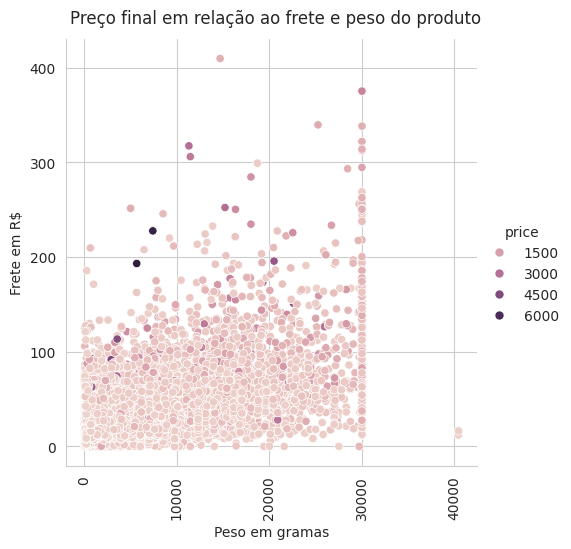

In [139]:
g = sns.relplot(x="product_weight_g" ,y= "freight_value",hue = "price" , data = df_master)
g.figure.suptitle("Preço final em relação ao frete e peso do produto", y = 1.03)
g.set(xlabel= "Peso em gramas", ylabel = "Frete em R$")
plt.xticks(rotation = 90)
sns.set_context("talk")
plt.show()

#Embora solicitada essa relação, é possivel ver que o preço não tem uma relação
#forte com o frete ou o peso do produto. Veja que na região de frete 200 e peso 5000
# é possivel encontrar os maiores preços (6.000,00). Em contrapartida, na região de frete de 380 e peso
#30000g (30kg) o preço é próximo de 3.000,00.